In [44]:
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
import torch

model_id = "openai/whisper-base"
processor = AutoProcessor.from_pretrained(model_id, attn_implementation="eager")
model = AutoModelForSpeechSeq2Seq.from_pretrained(model_id)
model.set_attn_implementation("eager")
model.eval()

Loading weights: 100%|██████████| 245/245 [00:00<00:00, 7237.82it/s]


WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 512, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(512, 512, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 512)
      (layers): ModuleList(
        (0-5): 6 x WhisperEncoderLayer(
          (self_attn): WhisperAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=False)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
   

In [45]:
import librosa
audio, sr = librosa.load(r"D:\Desktop\ml\data\data6.wav", sr=16000, mono=True)

In [46]:
inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
print(inputs["input_features"].shape)

torch.Size([1, 80, 3000])


In [47]:
import torch.nn as nn
import torch.nn.functional as F

class MiniEncoderStem(nn.Module):
  def __init__(self, n_mels=80, d_model=512):
    super().__init__()
    self.conv1 = nn.Conv1d(n_mels, d_model, kernel_size=3, padding=1)
    self.conv2 = nn.Conv1d(d_model, d_model, kernel_size=3, stride=2, padding=1)

  def forward(self, x):
    x = F.gelu(self.conv1(x))
    x = F.gelu(self.conv2(x))

    return x

stem = MiniEncoderStem()

x = inputs["input_features"]

stem.conv1.load_state_dict(model.model.encoder.conv1.state_dict())
stem.conv2.load_state_dict(model.model.encoder.conv2.state_dict())

with torch.no_grad():
  output = stem(x)


Часть 1. Self-attention внрутри Whisper

# 1

In [48]:
self_attn = model.model.encoder.layers[0].self_attn
print(self_attn)

WhisperAttention(
  (k_proj): Linear(in_features=512, out_features=512, bias=False)
  (v_proj): Linear(in_features=512, out_features=512, bias=True)
  (q_proj): Linear(in_features=512, out_features=512, bias=True)
  (out_proj): Linear(in_features=512, out_features=512, bias=True)
)


In [49]:
print("Размерность модели: ", model.config.d_model)
print("Количество голов encoder: ", model.config.encoder_attention_heads)
print("Размерность каждой головы: ", model.config.d_model // model.config.encoder_attention_heads)

Размерность модели:  512
Количество голов encoder:  8
Размерность каждой головы:  64


# 2

In [50]:
with torch.no_grad():
    encoder_output = model.model.encoder(
        input_features=inputs.input_features,
        output_attentions=True,
        return_dict=True,
    )

In [51]:
attentions = encoder_output.attentions[0]
attentions_head0 = attentions[0][0]
print(attentions.shape)
print(attentions_head0.shape)

torch.Size([1, 8, 1500, 1500])
torch.Size([1500, 1500])


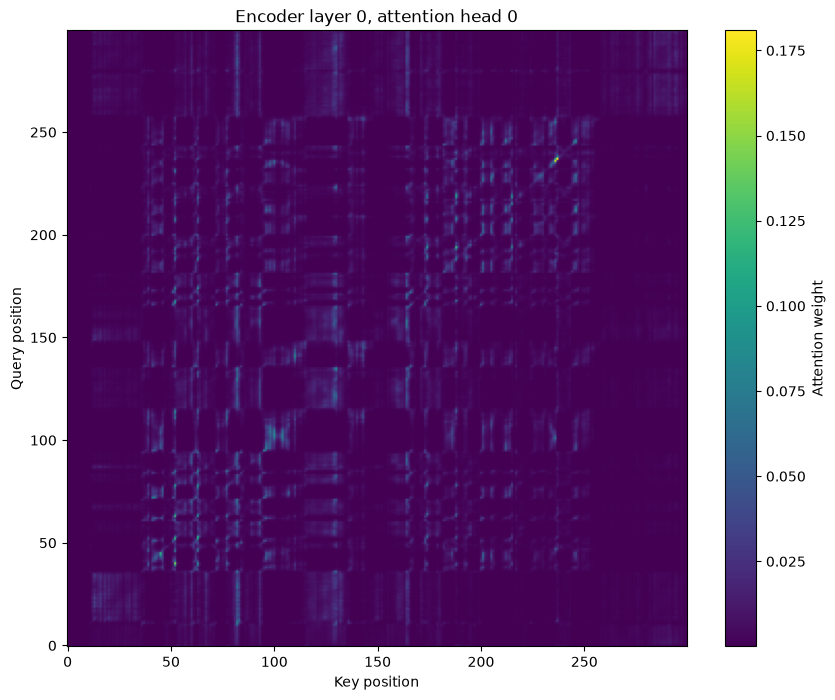

In [52]:
import matplotlib.pyplot as plt

attention_matrix = attentions_head0.detach().cpu().float().numpy()

plt.figure(figsize=(10, 8))
plt.imshow(
    attention_matrix[:300, :300],
    aspect="auto",
    origin="lower",
)
plt.colorbar(label="Attention weight")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.title("Encoder layer 0, attention head 0")
plt.show()

# 3

In [53]:
import math

class SingleHeadAttention(nn.Module):
  def __init__(self, d_model = 512, head_dim = 64):
    super().__init__()

    self.head_dim = head_dim

    self.q_proj = nn.Linear(
        d_model,
        head_dim,
        bias = True
    )

    self.k_proj = nn.Linear(
        d_model,
        head_dim,
        bias = False
    )

    self.v_proj = nn.Linear(
        d_model,
        head_dim,
        bias = True
    )

  def forward(self, x):
    q = self.q_proj(x)
    k = self.k_proj(x)
    v = self.v_proj(x)

    dotproduct = q @ k.transpose(-2, -1)
    dotproduct = dotproduct / math.sqrt(self.head_dim)

    attention_weights = torch.softmax(dotproduct, dim = -1)

    output = attention_weights @ v

    return output, attention_weights



Копирование весов матриц W_q, W_k, W_v

In [54]:
single_head_attention = SingleHeadAttention()

with torch.no_grad():
    single_head_attention.q_proj.weight.copy_(
        self_attn.q_proj.weight[0:64]
    )
    single_head_attention.q_proj.bias.copy_(
        self_attn.q_proj.bias[0:64]
    )

    single_head_attention.k_proj.weight.copy_(
        self_attn.k_proj.weight[0:64]
    )

    single_head_attention.v_proj.weight.copy_(
        self_attn.v_proj.weight[0:64]
    )
    single_head_attention.v_proj.bias.copy_(
        self_attn.v_proj.bias[0:64]
    )

Для подачи векторов в слой self-attention им нужно пройти через слой с добавлением позиционирования и нормализации

In [55]:
hidden_states = output.permute(0, 2, 1)

positions = torch.arange(
    hidden_states.shape[1],
    device = hidden_states.device
)

hidden_states = hidden_states + model.model.encoder.embed_positions(positions)

self_attn_input = model.model.encoder.layers[0].self_attn_layer_norm(hidden_states)

In [56]:
with torch.no_grad():
    single_head_attention_output, single_head_attention_weights = single_head_attention(self_attn_input)

Сравнение выходов 1 головы 1 слоя self_attention


In [57]:
diff = (single_head_attention_weights - attentions_head0).abs().max()
print(diff)
print(single_head_attention_weights.shape)
print(attentions_head0.shape)
print("max diff:", diff.item())

tensor(0.)
torch.Size([1, 1500, 1500])
torch.Size([1500, 1500])
max diff: 0.0


# 4.

Q, K, V получаются путем домножения на обучаемые матрицы весов W_q, W_k, W_v входных векторов. Q, K, V - вектора, которые имеют смысл запроса, ключа и значения соответсвенно при подачи во вход к слоям внимания. Например, для слоя self-attention энкодера для получения Q, K, V используются исходные вектора, а для слоя cross-attention между энкодером и декодером для получения K, V используются вектора из выхода энкодера, а для получения Q используются вектора из выхода слоя self-attention декодера для поиска связи именно между энкодером и декодером.

Формула подсчета внимания показывает смысл Q, K, V: мы смотрим на то, насколько каждый запрос соответствует каждому ключу через скалярное произведение (QK^T), потом делим на корень из их размерности для нормализации и распределения скалярного произведения в примерно одном масштабе, применяем softmax для получения весов внимания и умножаем на значения, которые соответствуют каждому вектору.

Whisper-tiny в каждом слое энкодера и декодера имеет 6 голов и размерность d_model 384, соответственно размерность каждой головы d_head будет 384 / 6 = 64

у Whisper-base же 512 размерность и 8 голов. Размерность головы также 64

# 5

data1 - "Рита Лаушкина"

data2 - "Леденящие душу приключения Сабрины, эпизод 9"

data3 - "Поставь игру челси и тотенхема"

data4 - "Юлии!"

data5 - "Какой у вас оператор?"

data6 - "Запись тестового сообщения с частотой 16 кгц для виспера"

In [58]:
from datasets import Dataset

ds = Dataset.from_dict({
    "audio": [
        r"D:\Desktop\ml\data\data1.wav",
        r"D:\Desktop\ml\data\data2.wav",
        r"D:\Desktop\ml\data\data3.wav",
        r"D:\Desktop\ml\data\data4.wav",
        r"D:\Desktop\ml\data\data5.wav",
        r"D:\Desktop\ml\data\data6.wav",
    ]
})

print(ds)

Dataset({
    features: ['audio'],
    num_rows: 6
})


In [59]:
from transformers import pipeline

pipe = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-base",
)

results = pipe(
    list(ds["audio"]),
    generate_kwargs = {"language": "ru", "task": "transcribe"},
)

predictions = [result["text"] for result in results]

print(predictions)

Loading weights: 100%|██████████| 245/245 [00:00<00:00, 5776.30it/s]


[' Рита Лаушкина', ' Ледянящие душу, приключения собрины, эпизод 9.', ' Постав и гручился и тот инхэма.', ' Юлии!', ' Какой у вас оператор?', ' Запись тестово с общения с 16 килогердпл. Виспером.']


# 6

In [60]:
import mlflow
import re
from pathlib import Path

db_path = Path(r"D:\Desktop\ml\mlflow.db")
tracking_uri = f"sqlite:///{db_path.as_posix()}"

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("whisper-practice")

reference_texts = [
    "Рита Лаушкина",
    "Леденящие душу приключения Сабрины, эпизод 9",
    "Поставь игру челси и тотенхема",
    "Юлии!",
    "Какой у вас оператор?",
    "Запись тестового сообщения с частотой 16 кгц для виспера"
]

def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return "".join(text.split())

matches = [
    int(normalize_text(prediction) == normalize_text(reference))
    for prediction, reference in zip(predictions, reference_texts)
]

match_accuracy = sum(matches) / len(matches)

config = pipe.model.config

with mlflow.start_run(run_name="whisper-base-all-audio") as run:
    mlflow.log_params({
        "d_model": config.d_model,
        "num_attention_heads": config.encoder_attention_heads
    })

    mlflow.log_metric(
        "match_accuracy",
        match_accuracy
    )

    for index, match in enumerate(matches):
        mlflow.log_metric(
            "match_accuracy_per_file",
            match,
            step = index + 1,
        )



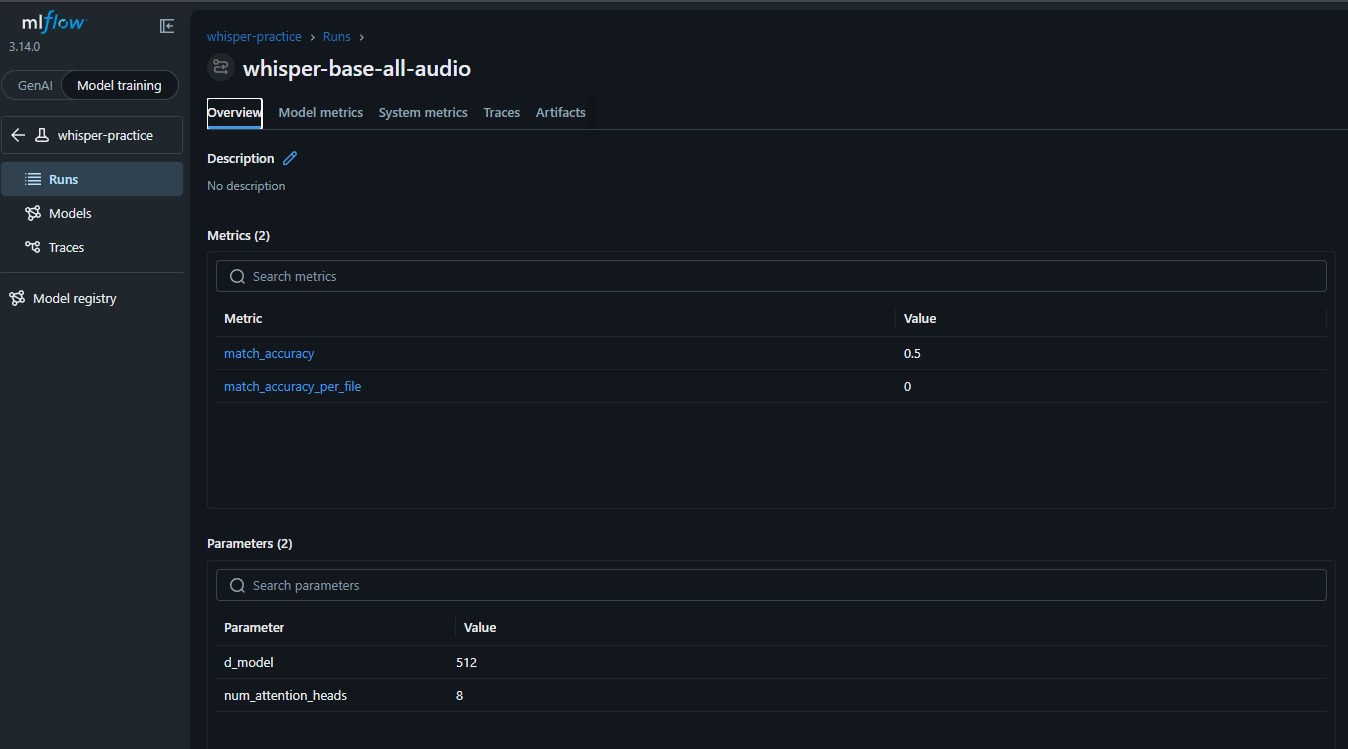
![alt text](image.png)

# Трек 1. HF-пайплайны и данные

In [61]:
import os
from datasets import load_dataset, Audio

os.environ["HF_HOME"] = r"D:\Desktop\ml\.hf-cache"

ds = load_dataset("google/fleurs", "ru_ru", cache_dir=r"D:\Desktop\ml\.hf-cache")

In [62]:
print(ds)

MIN_SAMPLES = 1 * 16_000
MAX_SAMPLES = 10 * 16_000
def suitable_duration(example):
    return MIN_SAMPLES <= example["num_samples"] <= MAX_SAMPLES

train_dataset = ds["train"].filter(suitable_duration)
validation_dataset = ds["validation"].filter(suitable_duration)

train_dataset = train_dataset.shuffle(seed=42)
validation_dataset = validation_dataset.shuffle(seed=42)

train_dataset = train_dataset.select(
    range(min(300, len(train_dataset)))
)

validation_dataset = validation_dataset.select(
    range(min(50, len(validation_dataset)))
)

train_dataset = train_dataset.cast_column(
    "audio",
    Audio(sampling_rate=16_000, num_channels=1),
)

validation_dataset = validation_dataset.cast_column(
    "audio",
    Audio(sampling_rate=16_000, num_channels=1),
)

print("Train:", len(train_dataset))
print("Validation:", len(validation_dataset))

print(train_dataset[1]["transcription"])
print(train_dataset[1]["num_samples"] / 16_000, "сек.")

DatasetDict({
    train: Dataset({
        features: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'],
        num_rows: 2562
    })
    validation: Dataset({
        features: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'],
        num_rows: 356
    })
    test: Dataset({
        features: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'],
        num_rows: 775
    })
})
Train: 300
Validation: 50
процесс проходил в бирмингемском суде короны и завершился 3 августа
8.94 сек.


In [63]:
example = train_dataset[0]
audio_decoder = example["audio"]
samples = audio_decoder.get_all_samples()

print("Форма:", samples.data.shape)
print("Частота:", samples.sample_rate)
print("Длительность:", samples.data.shape[-1] / samples.sample_rate)
print(example["transcription"])

Форма: torch.Size([1, 92160])
Частота: 16000
Длительность: 5.76
днём они холоднее чем окружающая поверхность а ночью теплее


In [64]:
processor = AutoProcessor.from_pretrained(
    "openai/whisper-tiny", 
    language="ru", 
    task="transcribe"
)
model = AutoModelForSpeechSeq2Seq.from_pretrained("openai/whisper-tiny")
model.generation_config.language = "ru"
model.generation_config.task = "transcribe"

print(train_dataset.features)

Loading weights: 100%|██████████| 167/167 [00:00<00:00, 4175.25it/s]


{'id': Value('int32'), 'num_samples': Value('int32'), 'path': Value('string'), 'audio': Audio(sampling_rate=16000, decode=True, num_channels=1, stream_index=None), 'transcription': Value('string'), 'raw_transcription': Value('string'), 'gender': ClassLabel(names=['male', 'female', 'other']), 'lang_id': ClassLabel(names=['af_za', 'am_et', 'ar_eg', 'as_in', 'ast_es', 'az_az', 'be_by', 'bg_bg', 'bn_in', 'bs_ba', 'ca_es', 'ceb_ph', 'ckb_iq', 'cmn_hans_cn', 'cs_cz', 'cy_gb', 'da_dk', 'de_de', 'el_gr', 'en_us', 'es_419', 'et_ee', 'fa_ir', 'ff_sn', 'fi_fi', 'fil_ph', 'fr_fr', 'ga_ie', 'gl_es', 'gu_in', 'ha_ng', 'he_il', 'hi_in', 'hr_hr', 'hu_hu', 'hy_am', 'id_id', 'ig_ng', 'is_is', 'it_it', 'ja_jp', 'jv_id', 'ka_ge', 'kam_ke', 'kea_cv', 'kk_kz', 'km_kh', 'kn_in', 'ko_kr', 'ky_kg', 'lb_lu', 'lg_ug', 'ln_cd', 'lo_la', 'lt_lt', 'luo_ke', 'lv_lv', 'mi_nz', 'mk_mk', 'ml_in', 'mn_mn', 'mr_in', 'ms_my', 'mt_mt', 'my_mm', 'nb_no', 'ne_np', 'nl_nl', 'nso_za', 'ny_mw', 'oc_fr', 'om_et', 'or_in', 'pa_in

In [65]:
def prepare_example(example):
    samples = example["audio"].get_all_samples()

    waveform = samples.data.squeeze(0).numpy()

    example["input_features"] = processor.feature_extractor(
        waveform,
        sampling_rate=samples.sample_rate,
    ).input_features[0]

    example["labels"] = processor.tokenizer(
        example["transcription"]
    ).input_ids

    return example

In [66]:
train_prepared = train_dataset.map(
    prepare_example,
    remove_columns=train_dataset.column_names,
)

validation_prepared = validation_dataset.map(
    prepare_example,
    remove_columns=validation_dataset.column_names,
)

In [67]:
from dataclasses import dataclass
from typing import Any

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    decoder_start_token_id: int

    def __call__(self, features):
        audio_features = [
            {"input_features": item["input_features"]} for item in features
        ]

        batch = self.processor.feature_extractor.pad(
            audio_features, 
            return_tensors = "pt"
        )

        text_features = [
            {"input_ids": item["labels"]}
            for item in features
        ]

        labels_batch = self.processor.tokenizer.pad(
            text_features,
            return_tensors="pt",
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch["attention_mask"].ne(1),
            -100,
        )

        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels

        return batch
    
data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor = processor,
    decoder_start_token_id=model.config.decoder_start_token_id
)





In [68]:
import evaluate

wer_metric = evaluate.load("wer")

def normalize(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = text.replace("_", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def compute_metrics(prediction):
    predicted_ids = prediction.predictions
    label_ids = prediction.label_ids.copy()

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    predicted_texts = processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )

    reference_texts = processor.batch_decode(
        label_ids,
        skip_special_tokens=True
    )

    predicted_texts = [normalize(text) for text in predicted_texts]
    reference_texts = [normalize(text) for text in reference_texts]

    wer = wer_metric.compute(
        predictions=predicted_texts,
        references=reference_texts
    )

    return {"wer": wer}



In [69]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="./whisper-tiny-full",

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,

    learning_rate=1e-5,
    num_train_epochs=2,

    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,

    predict_with_generate=True,

    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,

    save_total_limit=2,
    dataloader_num_workers=0,
    report_to="none",
)

In [70]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,

    train_dataset=train_prepared,
    eval_dataset=validation_prepared,

    data_collator=data_collator,
    compute_metrics=compute_metrics,

    processing_class=processor,
)

In [71]:
ds = Dataset.from_dict({
    "audio": [
        r"D:\Desktop\ml\data\data1.wav",
        r"D:\Desktop\ml\data\data2.wav",
        r"D:\Desktop\ml\data\data3.wav",
        r"D:\Desktop\ml\data\data4.wav",
        r"D:\Desktop\ml\data\data5.wav",
        r"D:\Desktop\ml\data\data6.wav",
    ],
    "transcription": [
        "Рита Лаушкина",
        "Леденящие душу приключения Сабрины, эпизод 9",
        "Поставь игру челси и тотенхема",
        "Юлии!",
        "Какой у вас оператор?",
        "Запись тестового сообщения с частотой 16 кгц для виспера"
    ]
})

ds = ds.cast_column(
    "audio",
    Audio(
        sampling_rate=16_000,
        num_channels=1,
    ),
)

final_test_prepared = ds.map(
    prepare_example,
    remove_columns=ds.column_names,
)

before = trainer.predict(
    final_test_prepared,
    metric_key_prefix="before"
)

before_texts = processor.batch_decode(
    before.predictions,
    skip_special_tokens=True
)

Map: 100%|██████████| 6/6 [00:00<00:00, 19.64 examples/s]


In [72]:
model_result = trainer.train()

Epoch,Training Loss,Validation Loss,Wer
1,3.141514,0.554611,0.292719
2,2.226537,0.522327,0.307578


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.12it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


In [73]:
print("Время обучения: ", model_result.metrics["train_runtime"])

Время обучения:  410.8219


In [74]:
after = trainer.predict(
    final_test_prepared,
    metric_key_prefix="after",
)

after_texts = processor.batch_decode(
    after.predictions,
    skip_special_tokens=True
)

In [75]:
print(before.metrics)
print(after.metrics)

print(before_texts)
print(after_texts)

{'before_loss': 1.7457417249679565, 'before_model_preparation_time': 0.0024, 'before_wer': 0.5925925925925926, 'before_runtime': 2.8077, 'before_samples_per_second': 2.137, 'before_steps_per_second': 1.068}
{'after_loss': 1.3686084747314453, 'after_model_preparation_time': 0.0024, 'after_wer': 0.5555555555555556, 'after_runtime': 2.5748, 'after_samples_per_second': 2.33, 'after_steps_per_second': 1.165}
[' Рита Лаушкина', ' Лидиящее душу петлючения сабриной эпизод 9.', ' постав и грудь и татан Хема', ' Юлия!', ' Какой у вас оператор?', ' Записте стого сообщения с 14 килогрт ловистпером.']
[' рита лаушкина', 'лединиащие душу петлючения сабриной эпизод 9', 'постав их ручился и тот он хемо', ' Юлия', 'какой у вас оператор', ' запись тестового сообщения с чувствуешь снатзе килогрт на виспиром']


# PEFT/LoRA

In [86]:
full_total_params = sum(
    parameter.numel()
    for parameter in trainer.model.parameters()
)

full_wer_after = after.metrics["after_wer"]

print("Общее число параметров:", full_total_params)

Общее число параметров: 37760640


In [77]:
lora_base_model = AutoModelForSpeechSeq2Seq.from_pretrained("openai/whisper-tiny")
lora_base_model.generation_config.language = "ru"
lora_base_model.generation_config.task = "transcribe"

Loading weights: 100%|██████████| 167/167 [00:00<00:00, 8218.91it/s]


In [78]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r = 8,
    lora_alpha = 16,
    target_modules=[
        "q_proj",
        "v_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    inference_mode=False
)

lora_model = get_peft_model(
    lora_base_model, 
    lora_config
)

lora_model.print_trainable_parameters()

trainable params: 147,456 || all params: 37,908,096 || trainable%: 0.3890


In [79]:
lora_training_args = Seq2SeqTrainingArguments(
    output_dir="./whisper-tiny-lora-output",

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,

    learning_rate=1e-4,
    num_train_epochs=2,

    warmup_ratio=0.1,
    lr_scheduler_type="linear",

    fp16=torch.cuda.is_available(),

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,

    predict_with_generate=True,
    generation_max_length=128,

    remove_unused_columns=False,
    label_names=["labels"],

    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,

    save_total_limit=2,
    dataloader_num_workers=0,

    seed=42,
    data_seed=42,

    report_to="none",
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [80]:
lora_trainer = Seq2SeqTrainer(
    model=lora_model, 
    args=lora_training_args,

    train_dataset=train_prepared,
    eval_dataset=validation_prepared,

    data_collator=data_collator,
    compute_metrics=compute_metrics,

    processing_class=processor
)

In [81]:
lora_before = lora_trainer.predict(
    final_test_prepared,
    metric_key_prefix="lora_before",
)

lora_before_text = processor.batch_decode(
    lora_before.predictions,
    skip_special_tokens=True
)

In [82]:
torch.cuda.reset_peak_memory_stats()

lora_train_result = lora_trainer.train()

Epoch,Training Loss,Validation Loss,Wer
1,4.019065,0.814773,0.304606
2,3.791660,0.774298,0.297177


In [83]:
print("Время обучения: ", lora_train_result.metrics["train_runtime"])

Время обучения:  297.457


In [84]:
lora_after = lora_trainer.predict(
    final_test_prepared,
    metric_key_prefix="lora_after"
)

lora_after_text = processor.batch_decode(
    lora_after.predictions,
    skip_special_tokens=True
)

In [85]:
print(lora_before.metrics)
print(lora_after.metrics)

print(lora_before_text)
print(lora_after_text)

{'lora_before_loss': 1.7457417249679565, 'lora_before_model_preparation_time': 0.0048, 'lora_before_wer': 0.5925925925925926, 'lora_before_runtime': 2.3753, 'lora_before_samples_per_second': 2.526, 'lora_before_steps_per_second': 1.263}
{'lora_after_loss': 1.5718460083007812, 'lora_after_model_preparation_time': 0.0048, 'lora_after_wer': 0.5555555555555556, 'lora_after_runtime': 2.265, 'lora_after_samples_per_second': 2.649, 'lora_after_steps_per_second': 1.324}
[' Рита Лаушкина', ' Лидиящее душу петлючения сабриной эпизод 9.', ' постав и грудь и татан Хема', ' Юлия!', ' Какой у вас оператор?', ' Записте стого сообщения с 14 килогрт ловистпером.']
[' рита лаушкина', ' Лидиящее душу петлючения сабриной эпизод 9', ' постав и грудь ялся и татан хема', ' Юлия', ' Какой у вас оператор?', ' запись тестового сообщения с 14 килогерт на виспюра']


# Результаты:

За тестовую выборку взято 6 wav файлов длиной записи до 10 секунд

wer Whisper до fine-tuning: 0.5925925925925926

wer Whisper после fine-tuning: 0.5555555555555556

транскрипции: [' рита лаушкина', 'лединиащие душу петлючения сабриной эпизод 9', 'постав их ручился и тот он хемо', ' Юлия', 'какой у вас оператор', ' запись тестового сообщения с чувствуешь снатзе килогрт на виспиром']

wer Whisper до дообучение LoRA: 0.5925925925925926

wer Whisper после дообучения LoRA: 0.5555555555555556

транскрипции: [' рита лаушкина', ' Лидиящее душу петлючения сабриной эпизод 9', ' постав и грудь ялся и татан хема', ' Юлия', ' Какой у вас оператор?', ' запись тестового сообщения с 14 килогерт на виспюра']

Fine-tuning занял 410 секунд, тогда как дообучение LoRA заняло 300 секунд.

fine-tuning обучал все параметры модели: 37 760 640

Дообучение LoRA обучало всего 147,456 параметров, остальные параметры были неподвижными

Конфигурации fine-tuning и LoRA немного различались.

Примечательно, что после fine-tuning и после дообучения LoRA транскрибация контрольной записи 
data6.wav стала лучше: транскрибировалось правильно два слова. Совпадение wer после дообучений обусловлено маленькой тестовой выборкой, видно, что результаты транскрибаций все равно разные.

In [87]:
repo_id = "alexanderKCHN/whisper-tiny-ru-lora"

lora_trainer.model.push_to_hub(
    repo_id,
    private=True,
    commit_message="Upload Whisper tiny Russian LoRA adapter",
)

processor.push_to_hub(
    repo_id,
    private=True,
    commit_message="Upload Whisper processor",
)

Processing Files (1 / 1): 100%|██████████|  596kB /  596kB, 48.4kB/s  
New Data Upload: 100%|██████████|  596kB /  596kB, 48.4kB/s  
d:\Desktop\ml\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Regard\.cache\huggingface\hub\models--alexanderKCHN--whisper-tiny-ru-lora. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  war

CommitInfo(commit_url='https://huggingface.co/alexanderKCHN/whisper-tiny-ru-lora/commit/97046602fd1684cfbb7bb7ad7a6fb5d2fe3ab398', commit_message='Upload Whisper processor', commit_description='', oid='97046602fd1684cfbb7bb7ad7a6fb5d2fe3ab398', pr_url=None, repo_url=RepoUrl('https://huggingface.co/alexanderKCHN/whisper-tiny-ru-lora', endpoint='https://huggingface.co', repo_type='model', repo_id='alexanderKCHN/whisper-tiny-ru-lora'), pr_revision=None, pr_num=None)